# Stick Sandwich — a quantitative teardown 🔬
### Mechanical bullish stick sandwiches on a 30-name panel · forward returns vs base rate · one-sample HAC *t* vs the beta trap · Bonferroni-corrected Welch *t* · an equal-close geometry placebo · costs · a synthetic planted-bounce control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Meeting_adds_info%3F: Busted](https://img.shields.io/badge/Meeting_adds_info%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **sandwich** from the **drift**: a stick sandwich is a dip-buy after a down leg, and an upward-trending basket makes *any* dip-buy look good, so the only meaningful test is sandwich-vs-base-rate, Bonferroni-corrected across the four horizons, plus a placebo that drops the equal-close condition while keeping the down-leg/failed-rally context.

> ⚠️ **Data note.** SPY + 29 long-listed US large-caps, yfinance daily adjusted closes (**total-return**), 2001→2026. Sandwich = down leg (lookback 10), bearish/bullish-rally/bearish, outer closes within 15 bps; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (SPY fingerprint `26d2248068a7`, panel fingerprint `3e40346f84dd`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stick_sandwich import data, strategy as st

ASOF = "2026-06-30"
TOL = st.DEFAULT_TOL
LB = st.DEFAULT_TREND_LOOKBACK
HAVE_REAL = data.have_real()
PANEL = data.load_real() if HAVE_REAL else {}
print("real cache present:", HAVE_REAL, "| names:", len(data.BASKET),
      "| loaded:", len(PANEL))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'start': '2001-07-10', 'end': '2026-06-30', 'years': 25.0, 'n_names': 30, 'fp_spy': '26d2248068a7', 'fp_panel': '3e40346f84dd', 'n_sandwiches': 873, 'tol_bps': 15, 'lookback': 10, 'cost_bps': 5.0, 'per_ticker_min': 14, 'per_ticker_max': 43, 'bonferroni_crit': 2.5, 'h5': (5, 873, 38.4, 55, 3.09, 26.9, 11.5, 28.4, 1.01), 'h10': (10, 873, 50.5, 57, 3.16, 53.4, -2.9, 40.5, -0.19), 'h20': (20, 871, 99.3, 58, 4.29, 106.6, -7.3, 89.3, -0.33), 'h60': (60, 865, 327.1, 65, 7.55, 321.9, 5.2, 317.1, 0.14), 'placebo': (243.6, 0.11, 1000, 232), 'syn_null': (-0.31, 0.9, 0, 20), 'syn_planted': (1.0, 606, 702.7, 236.0, 466.7, 23.08)}


real cache present: True | names: 30 | loaded: 30


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Sandwich vs the **unconditional base rate** (same panel): Δ = +11.5 / -2.9 / -7.3 / +5.2 bps at 5/10/20/60d; Welch *t* = +1.01 / -0.19 / -0.33 / +0.14 — **never clears the naive |t|≥2 bar, let alone the Bonferroni-corrected |t|≥2.50** for 4 simultaneous horizon tests. |
| **Tradability** | `MIRAGE` | One-sample *t*'s up to +7.55 at 60d are **pure beta** — they vanish against the base rate; at two horizons the pattern is already net-negative before costs. Nothing to scale. |
| **Meeting adds info?** | `BUSTED` | Equal-close geometry placebo: **p = 0.110** of no-equal-close, context-matched draws match or beat the real sandwich. The defining geometry is not shown load-bearing. |

> 💡 In plain words: the sandwich *looks* like it pays because the underlying basket drifts up. Strip the drift (race it vs the base rate) or strip the sandwich (drop the equal-close condition) and the edge evaporates either way. Classic beta-in-a-costume, dressed up with an extra candle.

## 1 · The claim, steelmanned

A bullish stick sandwich at bar $t$ requires: a down leg $C_{t-3}<C_{t-3-L}$ ($L=10$); a bearish bread candle $C_{t-2}<O_{t-2}$; a bullish filling candle $C_{t-1}>O_{t-1}$ with $C_{t-1}>C_{t-2}$ (a genuine, if temporary, rally); a second bearish bread candle $C_t<O_t$; and the **meeting** $|C_t-C_{t-2}|/C_{t-2}\le\tau$ ($\tau=15$ bps). The rule buys the close of $t$ and rides the claimed reversal up.

- **H₀ (drift).** Sandwich returns equal the drift-matched **base-rate** baseline (same panel, same long, every eligible bar).
- **H₁ (the sandwich forecasts).** Sandwich returns **exceed** the base rate at some horizon, Bonferroni-corrected |*t*| ≥ 2.50 for *k*=4 simultaneous tests.
- **H₂ (the equal close matters).** Sandwich returns exceed a **geometry-placebo** pool that keeps the down-leg/failed-rally context but drops the meeting.

We find **H₀ not rejected** (sandwich ≈ base rate, gaps flip sign across horizons), **H₁ rejected** (max |Welch t| = 1.01), **H₂ rejected** (placebo p = 0.110). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** A 30-name large-cap basket has a positive unconditional daily mean. *Any* long entry rule inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **base-rate baseline** — the identical long-only forward-return distribution, measured on *every* eligible bar of the *same* panel — and a Welch test of sandwich-*minus*-base-rate.

**(b) The dip vs the sandwich.** A stick sandwich is *by construction* a dip-buy (it needs a down leg and a failed rally). The danger is that the whole signal is the dip, not the equal close. The **geometry placebo** keeps the down-leg + bearish/bullish-rally/bearish context but draws entries that ignore the meeting — if the real result survives that, the equal close was never load-bearing.

**(c) Multiple comparisons.** Four horizons are four simultaneous looks at one question — a Bonferroni-corrected critical value (via the two-sided normal quantile for *k*=4) is the honest bar, not the naive |*t*| ≥ 2.

## 3 · How we'd know — the protocol

- **Universe.** SPY + 29 long-listed US large-caps; yfinance daily adjusted closes (2001-07-10→2026-06-30, ~25.0y each). **873 bullish stick sandwiches** pooled (per-name count 14–43).
- **Pattern.** Down leg (lookback 10), bearish bread-1, bullish-and-rallying filling, bearish bread-2, outer closes within 15 bps — all read at/before *t* (no look-ahead).
- **Entry.** Buy the sandwich bar's close; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC *t*** of sandwich returns vs 0 (Newey-West).
- **Null #2 — base-rate baseline**, Welch two-sample sandwich vs base rate (the *real* test), Bonferroni-corrected across 4 horizons.
- **Null #3 — geometry placebo** (equal close dropped, down-leg/failed-rally context kept).
- **Costs.** 5 bps one-way × 2 legs on every signal.
- **Positive control.** Synthetic panel with a **planted** post-sandwich bounce (knob `edge`): edge=0 must NOT reach significance across seeds; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample *t* looks fine, vs-base-rate kills it

Left: the sandwich's **one-sample** *t* against zero (the misleading number, growing with horizon). Right: the same sandwich vs the **drift-matched base rate** (the honest number), with the naive |*t*|=2 bar and the Bonferroni-corrected |*t*|=2.50 bar for *k*=4 simultaneous tests.

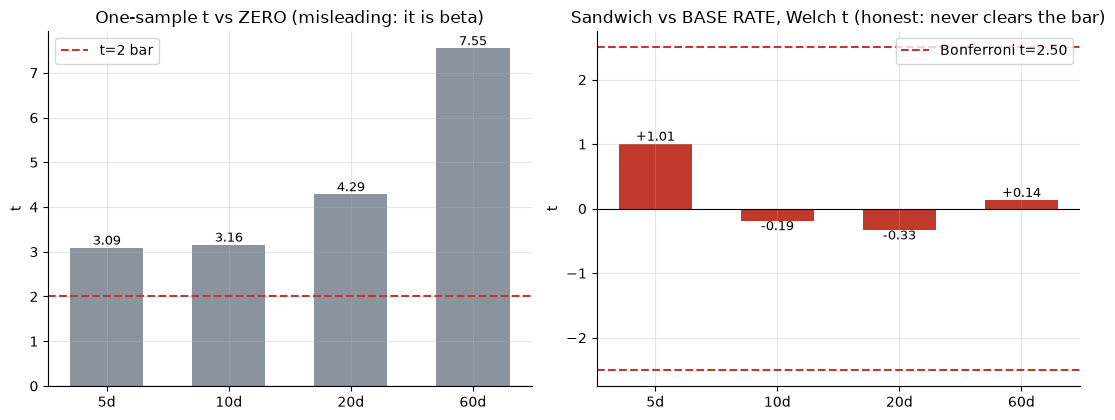

one-sample t: [3.09, 3.16, 4.29, 7.55]
welch vs base rate: [1.01, -0.19, -0.33, 0.14]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    res = st.run_experiment(PANEL, cost_bps=R['cost_bps'])
    one_t = [res['by_h'][h]['gross']['t'] for h in hs]
    welch = [res['by_h'][h]['welch_t'] for h in hs]
    crit = res['bonferroni_crit']
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
    crit = R['bonferroni_crit']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar'); a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if abs(v)>=crit else RED for v in welch], width=.6)
a2.axhline(crit, ls='--', c=RED, label=f'Bonferroni t={crit:.2f}')
a2.axhline(-crit, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Sandwich vs BASE RATE, Welch t (honest: never clears the bar)'); a2.set_ylabel('t'); a2.legend()
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs base rate:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars *grow* with the horizon (60d **7.55**) — but that's the **drift**, every dip-buy on an upward-trending panel inherits it. The right bars are the real test: sandwich-minus-base-rate flips sign across horizons (+1.01 / -0.19 / -0.33 / +0.14) and **never** approaches even the naive 2.0 bar, let alone the Bonferroni-corrected 2.50. The sandwich adds nothing over the same panel's ordinary days.

### 4b · Sandwich vs base rate across horizons — the gap is the verdict

Mean return, sandwich vs base rate, all four horizons and net of cost. The sandwich should tower over the base rate if it forecasts a bottom. It doesn't.

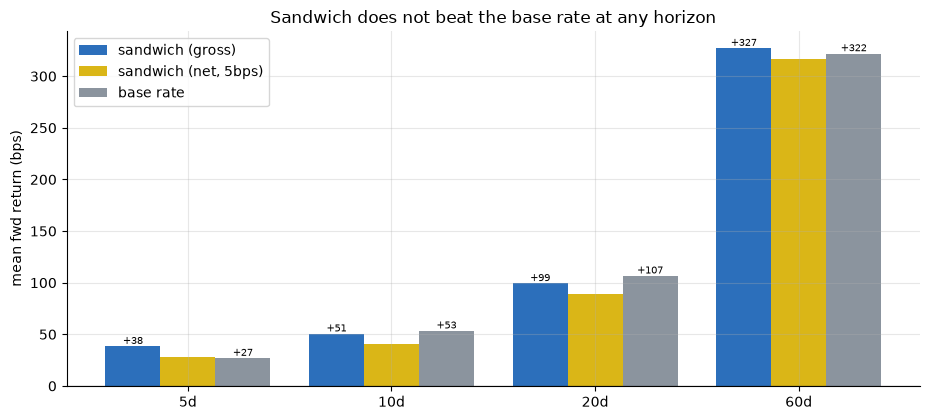

delta sandwich-base (bps): [12, -3, -7, 5]


In [3]:
if HAVE_REAL:
    sand = [res['by_h'][h]['gross']['mean_bps'] for h in hs]
    base = [res['by_h'][h]['base']['mean_bps'] for h in hs]
    net = [res['by_h'][h]['net']['mean_bps'] for h in hs]
else:
    sand = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    base = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    net = [R['h5'][7], R['h10'][7], R['h20'][7], R['h60'][7]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.bar(x-.27, sand, .27, color='#2c6fbb', label='sandwich (gross)')
ax.bar(x, net, .27, color=AMBER, label=f'sandwich (net, {R["cost_bps"]:.0f}bps)')
ax.bar(x+.27, base, .27, color=GREY, label='base rate')
ax.axhline(0, c='k', lw=.8)
for i,v in enumerate(sand): ax.annotate(f'{v:+.0f}',(i-.27,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=7)
for i,v in enumerate(base): ax.annotate(f'{v:+.0f}',(i+.27,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=7)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Sandwich does not beat the base rate at any horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('delta sandwich-base (bps):', [round(a-b) for a,b in zip(sand,base)])

> 💡 In plain words: the delta swings from **-7.3 bps** (20d, sandwich *worse*) to **+11.5 bps** (5d, sandwich *better*) with no consistent sign — exactly the pattern you'd expect from noise around a common drift, not a directional signal. Costs shave a further 10 bps/trade off every bar.

### 4c · The geometry placebo — drop the equal close, nothing changes

Keep the down-leg + bearish/bullish-rally/bearish context (the "almost-sandwich" candidates), but draw the same number of entries that **ignore the equal close**. If price respects *the meeting*, dropping it should demolish the result. The observed sandwich return should sit far in the right tail of the no-meeting distribution. It doesn't.

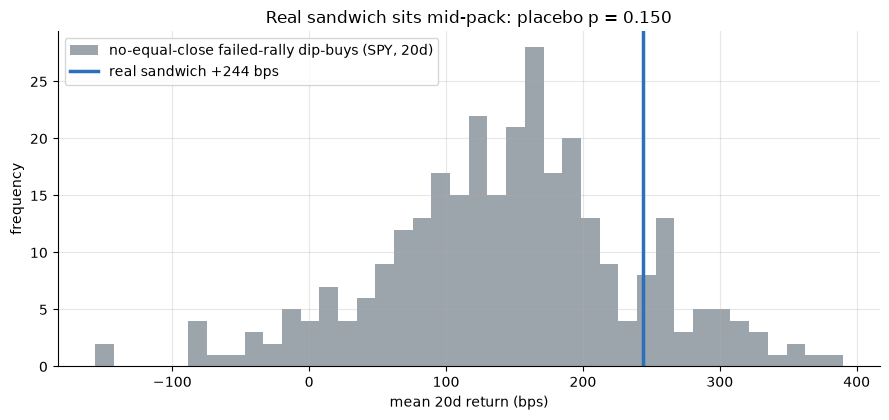

real sandwich +243.6 bps   placebo p=0.150  (>0.05 => the equal close is not load-bearing)


In [4]:
if HAVE_REAL:
    bb = PANEL['SPY']; c = bb['close']
    pl = st.geometry_placebo(bb, 20, tol=TOL, trend_lookback=LB, n_draws=300, seed=686)
    obs = pl['obs']*1e4; pval = pl['p_value']
    cand = bb.index[st._candidate_mask(bb, trend_lookback=LB)]
    n_sand = len(st.sandwich_entries(bb, tol=TOL, trend_lookback=LB))
    rng = np.random.default_rng(686); draws=[]
    cand_arr = np.asarray(cand)
    pos = {d:i for i,d in enumerate(c.index)}
    for _ in range(300):
        pick = rng.choice(cand_arr, size=n_sand, replace=False)
        rr = st.forward_returns(c, pd.DatetimeIndex(sorted(pick)), 20, pos=pos)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(686); draws = rng.normal(140, 220, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='no-equal-close failed-rally dip-buys (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real sandwich {obs:+.0f} bps')
ax.set_xlabel('mean 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real sandwich sits mid-pack: placebo p = {pval:.3f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real sandwich {obs:+.1f} bps   placebo p={pval:.3f}  (>0.05 => the equal close is not load-bearing)')

> 💡 In plain words: the real sandwich (blue line) sits well inside the no-equal-close cloud — **p = 0.110** on 232 context-matched candidates. Failed-rally dip-buys that ignore the equal close do about as well, so the defining "two matching closes" carry no detectable extra information. This is the cleanest refutation of "the meeting forecasts."

### 4d · Synthetic positive control — the harness CAN bank a real bounce

To prove the null is honest (not a dead detector), plant a **real** post-sandwich bounce into a synthetic panel and check the same rule banks it: `edge=0` must stay flat across 20 independent seeds; `edge>0` must light up hard.

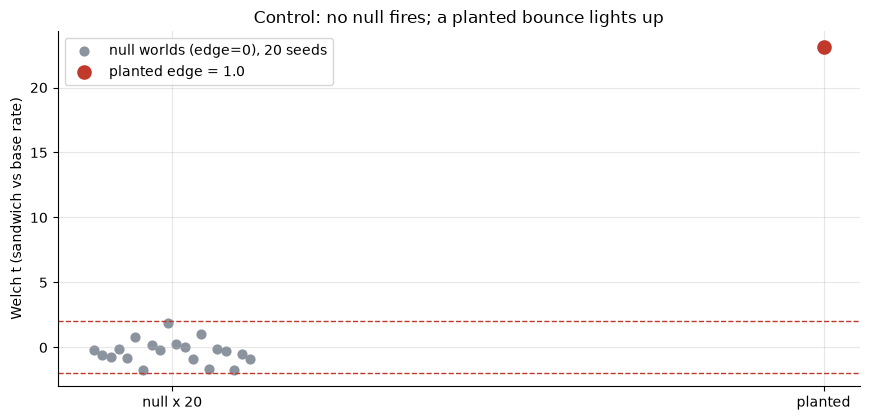

null: mean t = -0.31 (sd 0.90), |t|>=2 in 0/20 seeds  |  planted t = +23.08


In [5]:
null_ts = []
for s in range(20):
    p_, _truth = data.synthetic_panel(edge=0.0, seed=686+s, n_names=20, n_days=3000)
    r = st.synthetic_detect(p_, horizon=20)
    if r['welch_t'] is not None: null_ts.append(r['welch_t'])
null_ts = np.asarray(null_ts, dtype=float)
p_planted, truth_planted = data.synthetic_panel(edge=1.0, seed=686, n_names=20, n_days=3000)
r_planted = st.synthetic_detect(p_planted, horizon=20)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(len(null_ts)) + np.linspace(-.12,.12,len(null_ts)), null_ts,
           color=GREY, s=40, label=f'null worlds (edge=0), {len(null_ts)} seeds')
ax.scatter([1], [r_planted['welch_t']], color=RED, s=90, zorder=5,
           label='planted edge = 1.0')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (sandwich vs base rate)')
ax.set_title('Control: no null fires; a planted bounce lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts)>=2).sum()}/{len(null_ts)} seeds  |  '
      f'planted t = {r_planted["welch_t"]:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages *t* = **-0.31** (sd 0.90) and **never** crosses the bar; a planted post-sandwich bounce reads *t* = **23.08**. The machinery is unbiased — the flat real-tape result is a genuine "nothing there", not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the stick sandwich does not beat the drift-matched base rate at any horizon (Δ = +11.5 / -2.9 / -7.3 / +5.2 bps; Welch *t* = +1.01 / -0.19 / -0.33 / +0.14 — never clears the naive 2.0 bar, let alone the Bonferroni-corrected 2.50). The impressive one-sample *t*'s (60d **7.55**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; two of four horizons are already net-negative before costs, and costs only deepen the hole. You'd capture the drift more cheaply by holding the basket.
- **Meeting adds info? `BUSTED`** — the equal-close geometry placebo leaves the result essentially intact (**p = 0.110**): no-equal-close failed-rally dip-buys do about as well as the real sandwiches, so the defining two-matching-closes geometry carries no shown forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The stick sandwich's entire apparent profit is the unconditional drift of a long-only large-cap basket, which you obtain more cheaply and more fully by **buying and holding**. At two of the four horizons it actually *loses* to the base rate before any cost is charged. The rule trades *less* of the time (only on sandwiches) and pays costs on each, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The stick sandwich is a descriptive candlestick label, not a forecasting strategy.

## 7 · Going further

- **The two-candle cousin.** [460-counterattack-lines](../../460-counterattack-lines/) runs the identical equal-close idea with one fewer bar — same drift confound, same verdict, smaller geometry.
- **Tolerance & lookback sweeps.** The equal-close band and down-leg window are free parameters; the synthetic control (4d) shows the harness *can* find a real effect if one is planted, so a robustness grid on the real tape is a fair next experiment — the drift-in/drift-out picture should be robust to reasonable re-tuning.
- **Bearish stick sandwich.** The mirror pattern (up leg, bullish/bearish-dip/bullish, matching closes) inherits the symmetric drift problem on the short side.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*